In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()

db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_name = os.getenv('DB_NAME')

engine = create_engine(f'postgresql://{db_user}:{db_password}@{db_host}/{db_name}')

pd.read_sql("SELECT COUNT(*) FROM customers", engine)

In [3]:
query_rfm = """
WITH rfm_scores AS (
    SELECT 
        id,
        NTILE(4) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(4) OVER (ORDER BY (num_deals_purchases + num_web_purchases + num_catalog_purchases + num_store_purchases) ASC) AS f_score,
        NTILE(4) OVER (ORDER BY (mnt_wines + mnt_fruits + mnt_meat_products + mnt_fish_products + mnt_sweet_products + mnt_gold_prods) ASC) AS m_score
    FROM customers
),
rfm_final AS (
    SELECT 
        id,
        ROUND((r_score + f_score + m_score) / 3.0, 2) AS rfm_promedio
    FROM rfm_scores
),
rfm_segmentado AS (
    SELECT 
        id,
        rfm_promedio,
        CASE
            WHEN rfm_promedio >= 3.34 THEN 'Campeón'
            WHEN rfm_promedio >= 2.67 THEN 'Cliente leal'
            WHEN rfm_promedio >= 2.0  THEN 'Necesita atención'
            WHEN rfm_promedio >= 1.34 THEN 'En riesgo'
            ELSE 'Perdido'
        END AS segmento
    FROM rfm_final
)
SELECT 
    segmento,
    COUNT(*) AS total_clientes,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS porcentaje
FROM rfm_segmentado
GROUP BY segmento
ORDER BY total_clientes DESC;
"""

df_rfm = pd.read_sql(query_rfm, engine)
df_rfm

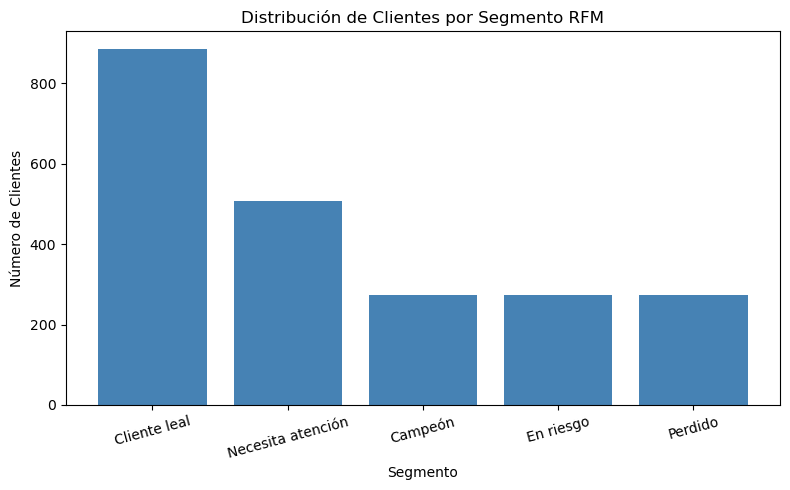

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(df_rfm['segmento'], df_rfm['total_clientes'], color='steelblue')
plt.title('Distribución de Clientes por Segmento RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../docs/segmentos_rfm.png', dpi=150)
plt.show()

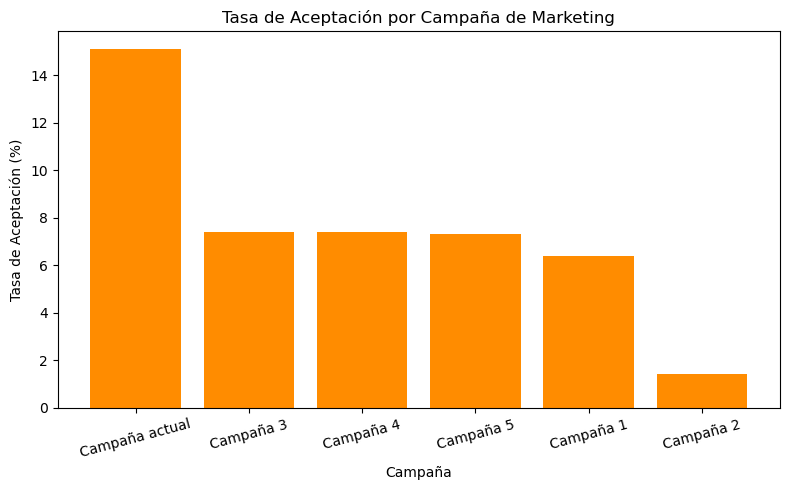

In [5]:
query_campanas = """
SELECT 
    'Campaña 1' AS campana, ROUND(100.0 * AVG(accepted_cmp1), 1) AS tasa_aceptacion FROM customers
UNION ALL
SELECT 
    'Campaña 2', ROUND(100.0 * AVG(accepted_cmp2), 1) FROM customers
UNION ALL
SELECT 
    'Campaña 3', ROUND(100.0 * AVG(accepted_cmp3), 1) FROM customers
UNION ALL
SELECT 
    'Campaña 4', ROUND(100.0 * AVG(accepted_cmp4), 1) FROM customers
UNION ALL
SELECT 
    'Campaña 5', ROUND(100.0 * AVG(accepted_cmp5), 1) FROM customers
UNION ALL
SELECT 
    'Campaña actual', ROUND(100.0 * AVG(response), 1) FROM customers
ORDER BY tasa_aceptacion DESC;
"""

df_campanas = pd.read_sql(query_campanas, engine)

plt.figure(figsize=(8, 5))
plt.bar(df_campanas['campana'], df_campanas['tasa_aceptacion'], color='darkorange')
plt.title('Tasa de Aceptación por Campaña de Marketing')
plt.xlabel('Campaña')
plt.ylabel('Tasa de Aceptación (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../docs/tasa_campanas.png', dpi=150)
plt.show()

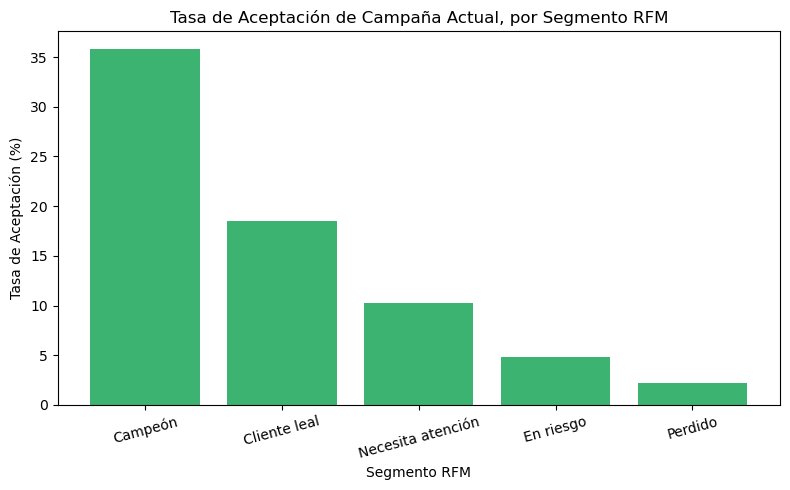

In [6]:
query_rfm_campana = """
WITH rfm_scores AS (
    SELECT 
        id,
        NTILE(4) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(4) OVER (ORDER BY (num_deals_purchases + num_web_purchases + num_catalog_purchases + num_store_purchases) ASC) AS f_score,
        NTILE(4) OVER (ORDER BY (mnt_wines + mnt_fruits + mnt_meat_products + mnt_fish_products + mnt_sweet_products + mnt_gold_prods) ASC) AS m_score
    FROM customers
),
rfm_segmentado AS (
    SELECT 
        id,
        CASE
            WHEN ROUND((r_score + f_score + m_score) / 3.0, 2) >= 3.34 THEN 'Campeón'
            WHEN ROUND((r_score + f_score + m_score) / 3.0, 2) >= 2.67 THEN 'Cliente leal'
            WHEN ROUND((r_score + f_score + m_score) / 3.0, 2) >= 2.0  THEN 'Necesita atención'
            WHEN ROUND((r_score + f_score + m_score) / 3.0, 2) >= 1.34 THEN 'En riesgo'
            ELSE 'Perdido'
        END AS segmento
    FROM rfm_scores
)
SELECT 
    r.segmento,
    ROUND(100.0 * AVG(c.response), 1) AS tasa_aceptacion
FROM rfm_segmentado r
JOIN customers c ON r.id = c.id
GROUP BY r.segmento
ORDER BY tasa_aceptacion DESC;
"""

df_rfm_campana = pd.read_sql(query_rfm_campana, engine)

plt.figure(figsize=(8, 5))
plt.bar(df_rfm_campana['segmento'], df_rfm_campana['tasa_aceptacion'], color='mediumseagreen')
plt.title('Tasa de Aceptación de Campaña Actual, por Segmento RFM')
plt.xlabel('Segmento RFM')
plt.ylabel('Tasa de Aceptación (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../docs/rfm_vs_campana.png', dpi=150)
plt.show()